In [13]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from multiprocessing import cpu_count

# プロジェクトルートをパスに追加
current_dir = os.path.dirname(os.path.abspath('.'))
sys.path.append(current_dir)
sys.path.append(os.path.abspath(os.path.join(current_dir, "..")))


from simulation.hawkes import HawkesParams, kernel_exp, kernel_pow, thinning_rate, lamb_i
from simulation.network import ER, Network

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [15]:
N = 100

In [17]:
# event_data = np.load(os.path.join(current_dir, "workers", "hawkes_worker_00.npz"), allow_pickle=True)
event_data = np.load(os.path.join(current_dir, f"data_ER_N={N}_pow", "03_results.npz"), allow_pickle=True)
network_data = np.load(os.path.join(current_dir, f"data_ER_N={N}_pow", "03_network.npz"), allow_pickle=True)

event_times = event_data["event_times"]
event_nodes = event_data["event_nodes"]

print(f"event_times.shape: {event_times.shape}")
print(f"event_nodes.shape: {event_nodes.shape}")

print(f"event_times[0, 0]: {event_times[0, 0]}")
print(f"event_nodes[0, 0]: {event_nodes[0, 0]}")


event_times.shape: (100, 40)
event_nodes.shape: (100, 40)
event_times[0, 0]: [0]
event_nodes[0, 0]: [28]


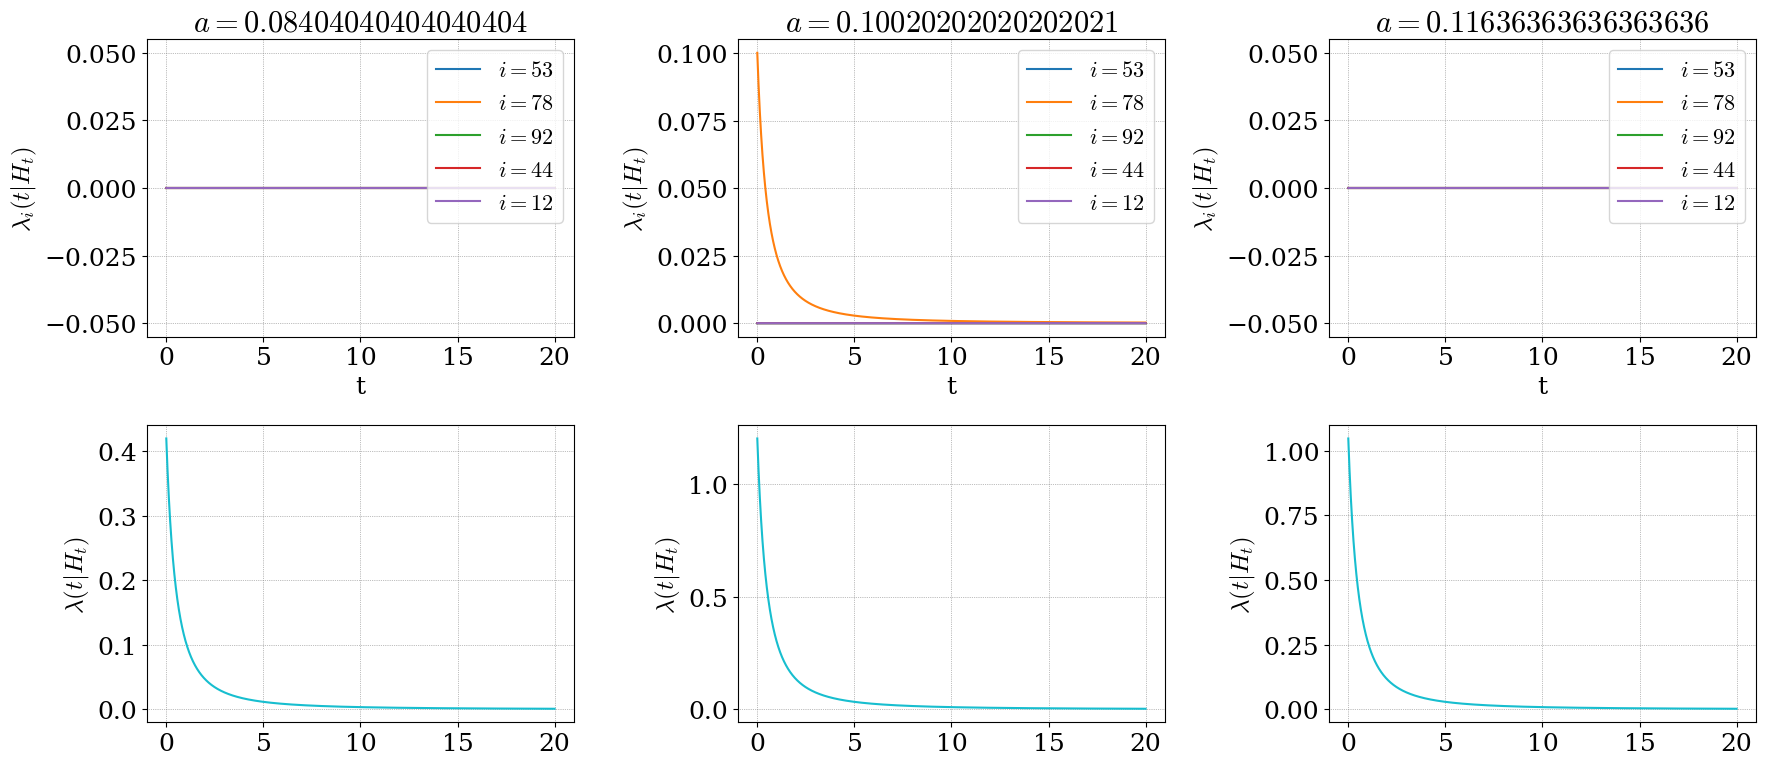

In [21]:
## TODO: paramsのデータから自動的にa_valuesを取得する
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

N = network_data["N"]
k_ave = network_data["k_ave"]
edge_list = network_data["edge_list"]
address_list = network_data["address_list"]
cursor_list = network_data["cursor_list"]
network = Network(N, k_ave, edge_list, address_list, cursor_list)
a_values = np.load(os.path.join(current_dir, f"data_ER_N={N}_pow", "a_values.npy"))

t = np.arange(0, 20, 0.001)
a_idx_list = [10, 50, 90]
which_repeat = 2

iidx_list = np.random.choice(range(N), size=5, replace=False)

fig, axes = plt.subplots(
    nrows=2,
    ncols=len(a_idx_list),
    figsize=(6 * len(a_idx_list), 8),
)

for idx, a_idx in enumerate(a_idx_list):
    a = a_values[a_idx]
    params = HawkesParams(kernel=kernel_pow, dim=N, a=a, b=1, K=a, c=1, theta=1)
    # event_data = np.load(os.path.join(current_dir, "workers", f"hawkes_worker_{a_idx:02d}.npz"), allow_pickle=True)
    event_times = event_data["event_times"][a_idx, which_repeat]
    event_nodes = event_data["event_nodes"][a_idx, which_repeat]

    for iidx, i in enumerate(iidx_list):
        lam_i_t = lamb_i(i=i, t=t, event_times=event_times, event_nodes=event_nodes, p=params, g=network)

        # ax.scatter(ti, lambs, s=3, color="tab:blue")
        axes[0, idx].plot(t, lam_i_t, color=colors[iidx], label=rf"$i = {i}$")
    axes[0, idx].set_xlabel("t")
    axes[0, idx].set_ylabel(rf"$\lambda_i(t|H_t)$")
    axes[0, idx].set_title(rf"$a = {a}$")
    axes[0, idx].grid(linestyle=":")
    axes[0, idx].legend()

    lam_t = np.array([lamb_i(i, t, event_times, event_nodes, params, network) for i in range(network.N)]).sum(axis=0)
    axes[1, idx].plot(t, lam_t, color=colors[-1])
    axes[1, idx].set_ylabel(rf"$\lambda(t|H_t)$")
    axes[1, idx].grid(linestyle=":")
fig.tight_layout()
plt.show()

In [22]:
cur_event_data = np.load(os.path.join(current_dir, f"data_ER_N={N}_pow", f"05_results.npz"), allow_pickle=True)

idxa = 90
a = a_values[idxa]
idxw_list = np.arange(0, 40, 2)
print(f"a: {a}")
for idxw in idxw_list:
    print(f"idxw: {idxw}")
    print(f"event_nodes: {cur_event_data['event_nodes'][idxa, idxw]}")
    print(f"event_times: {cur_event_data['event_times'][idxa, idxw]}")
    print(f"event_num: {cur_event_data['event_times'][idxa, idxw].shape[0]}")
    print()

a: 0.11636363636363636
idxw: 0
event_nodes: [ 2  2 10]
event_times: [0.         0.04144819 1.23457604]
event_num: 3

idxw: 2
event_nodes: [4]
event_times: [0]
event_num: 1

idxw: 4
event_nodes: [17 17]
event_times: [0.         0.81604587]
event_num: 2

idxw: 6
event_nodes: [12]
event_times: [0]
event_num: 1

idxw: 8
event_nodes: [88 88]
event_times: [0.         5.84500003]
event_num: 2

idxw: 10
event_nodes: [17]
event_times: [0]
event_num: 1

idxw: 12
event_nodes: [37]
event_times: [0]
event_num: 1

idxw: 14
event_nodes: [35]
event_times: [0]
event_num: 1

idxw: 16
event_nodes: [81]
event_times: [0]
event_num: 1

idxw: 18
event_nodes: [63]
event_times: [0]
event_num: 1

idxw: 20
event_nodes: [56]
event_times: [0]
event_num: 1

idxw: 22
event_nodes: [65]
event_times: [0]
event_num: 1

idxw: 24
event_nodes: [33]
event_times: [0]
event_num: 1

idxw: 26
event_nodes: [13]
event_times: [0]
event_num: 1

idxw: 28
event_nodes: [77]
event_times: [0]
event_num: 1

idxw: 30
event_nodes: [18]
eve

/var/folders/x_/xh9wlw410pvfbxgn1v4jp1300000gn/T/ipykernel_54614/2358646785.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


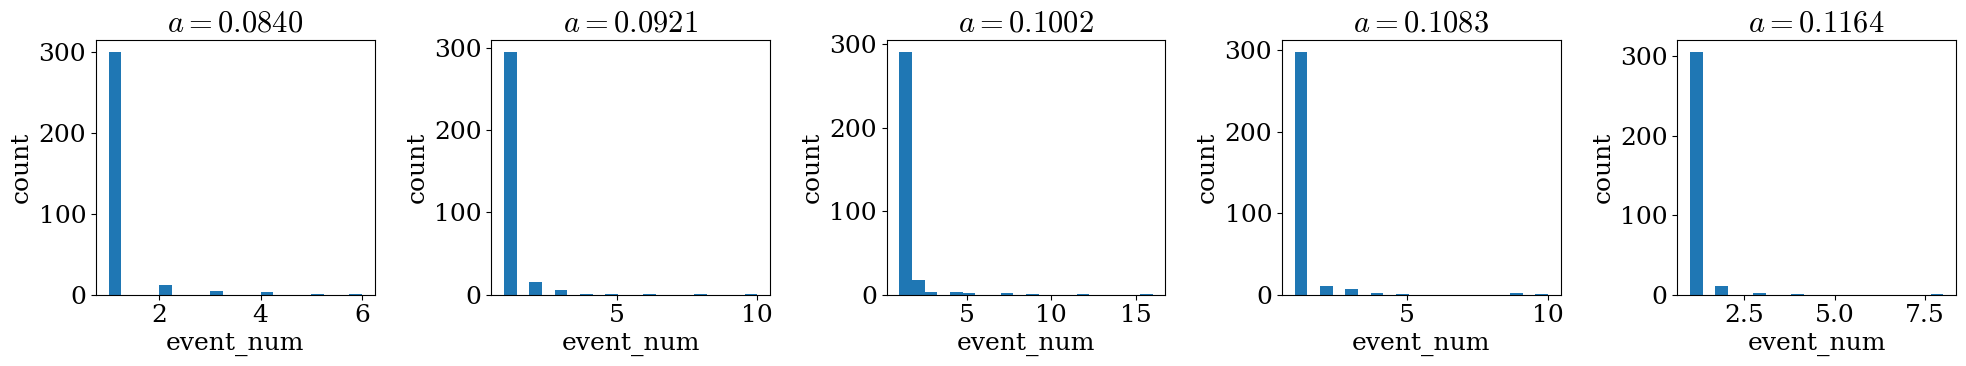

In [23]:
repeats = event_data["event_times"].shape[1]
num_workers = cpu_count()
a_idx_list = [10, 30, 50, 70, 90]
event_num = np.zeros((len(a_idx_list), repeats * num_workers))


for idx, a_idx in enumerate(a_idx_list):
    a = a_values[a_idx]

    for repeat_idx in range(repeats):
        for worker_id in range(cpu_count()):
            cur_event_data = np.load(os.path.join(current_dir, f"data_ER_N={N}_pow", f"{worker_id:02d}_results.npz"), allow_pickle=True)
            event_num[idx, repeat_idx * num_workers + worker_id] = cur_event_data["event_times"][idx, repeat_idx].shape[0]

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(a_idx_list),
    figsize=(4 * len(a_idx_list), 4),
)
for idx, a_idx in enumerate(a_idx_list):
    axes[idx].hist(event_num[idx], bins=20)
    axes[idx].set_xlabel("event_num")
    axes[idx].set_ylabel("count")
    axes[idx].set_title(rf"$a = {a_values[a_idx]:.4f}$")

fig.tight_layout()
fig.show()

In [28]:
len_args = event_data["event_times"].shape[0]
repeats = event_data["event_times"].shape[1]

shape = (len_args, repeats * cpu_count())
event_times = np.zeros(shape, dtype=np.ndarray)
event_nodes = np.zeros(shape, dtype=np.ndarray)

for i in range(len_args):
    if i % 10 ==0 or i == len_args-1:
        print(f"i: {i}")
    for worker_id in range(cpu_count()):
        cur_event_data = np.load(os.path.join(current_dir, f"data_ER_N={N}_pow", f"{worker_id:02d}_results.npz"), allow_pickle=True)
        event_times[i, worker_id * repeats:(worker_id + 1) * repeats] = cur_event_data["event_times"][i]
        event_nodes[i, worker_id * repeats:(worker_id + 1) * repeats] = cur_event_data["event_nodes"][i]

print(event_times.shape)
print(event_nodes.shape)

i: 0
i: 10
i: 20
i: 30
i: 40
i: 50
i: 60
i: 70
i: 80
i: 90
i: 99
(100, 320)
(100, 320)


a_idx: 30
 --> worker_id: 0
 --> worker_id: 4
a_idx: 35
 --> worker_id: 0
 --> worker_id: 4
a_idx: 40
 --> worker_id: 0
 --> worker_id: 4


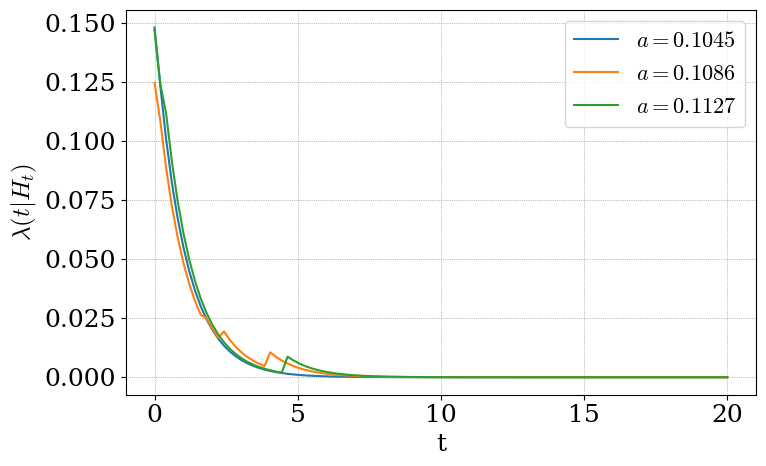

In [25]:
## TODO: paramsのデータから自動的にa_valuesを取得する

N = network_data["N"]
k_ave = network_data["k_ave"]
edge_list = network_data["edge_list"]
address_list = network_data["address_list"]
cursor_list = network_data["cursor_list"]
network = Network(N, k_ave, edge_list, address_list, cursor_list)

t = np.linspace(0, 20, 100)
na = 50
a_values = np.linspace(0.08, 0.12, na)
lamb_ave_a = np.zeros((len(a_values), len(t)))

fig, axes = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8, 5),
)

a_idx_list = [30, 35, 40]

for idx, a_idx in enumerate(a_idx_list):
    a = a_values[a_idx]
    is_print = True
    if is_print:
        print(f"a_idx: {a_idx}")
    for worker_id in range(cpu_count()):
        if is_print and worker_id%4 == 0:
            print(f" --> worker_id: {worker_id}")
        cur_network_data = np.load(os.path.join(current_dir, "data", f"{worker_id:02d}_network.npz"), allow_pickle=True)
        cur_network = Network(cur_network_data["N"], cur_network_data["k_ave"], cur_network_data["edge_list"], cur_network_data["address_list"], cur_network_data["cursor_list"])

        params = HawkesParams(kernel=kernel, dim=N, a=a, b=1)
        lam_t = np.zeros(len(t))
        for repeat_idx in range(repeats):
            lam_t += np.array([lamb_i(i, t, event_times[a_idx, worker_id * repeats + repeat_idx], event_nodes[a_idx, worker_id * repeats + repeat_idx], params, cur_network) for i in range(cur_network.N)]).sum(axis=0)

    lamb_ave_a[a_idx] = lam_t / (repeats * cpu_count())

for a_idx in a_idx_list:
    axes.plot(t, lamb_ave_a[a_idx], label=rf"$a = {a_values[a_idx]:.4f}$")
axes.set_xlabel("t")
axes.set_ylabel(rf"$\lambda(t|H_t)$")
axes.grid(linestyle=":")
axes.legend()
fig.tight_layout()
plt.show()

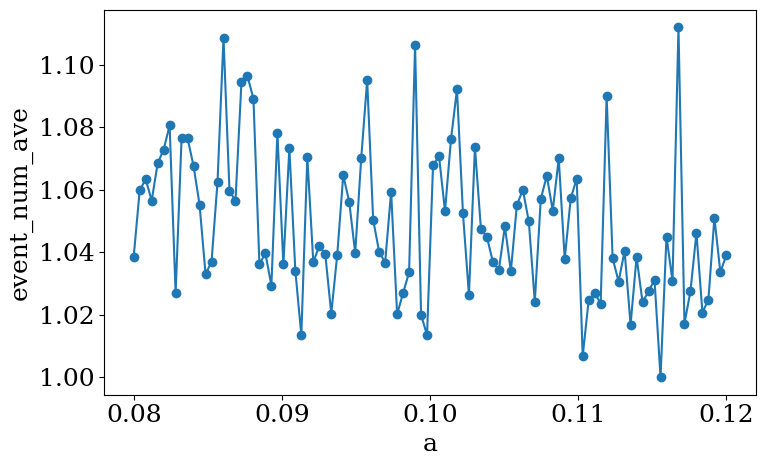

In [29]:
import os
import numpy as np
from multiprocessing import cpu_count
import matplotlib.pyplot as plt

#---- 設定 ----
data_dir = os.path.join(current_dir, f"data_BA_N={N}")
n_workers = cpu_count()
A = len(a_values)
R = repeats

#---- 1) 各 worker の event_times をキャッシュ ----
worker_data = []
for wid in range(n_workers):
    path = os.path.join(data_dir, f"{wid:02d}_results.npz")
    with np.load(path, allow_pickle=True) as d:
        # d["event_times"] は shape=(A, R) の object 配列
        worker_data.append(d["event_times"])

#---- 2) 合計長さ＆有効サンプル数を a_idx ごとに初期化 ----
total_lengths = np.zeros(A, dtype=float)
valid_counts  = np.zeros(A, dtype=int)

#---- 3) 各 worker のデータから集計 ----
for ev_times in worker_data:
    # 各要素の長さを一括取得 (shape=(A, R))
    lengths = np.vectorize(lambda arr: arr.shape[0])(ev_times)
    # 長さが 100001 でないものだけをカウント対象に
    mask = (lengths != 100001)

    # a_idx ごとに合計長さを足し込み
    total_lengths += (lengths * mask).sum(axis=1)
    # a_idx ごとに有効サンプル数を足し込み
    valid_counts  += mask.sum(axis=1)

#---- 4) 平均を計算 ----
event_num_ave = total_lengths / valid_counts

#---- 5) 描画 ----
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(a_values, event_num_ave, marker="o")
ax.set_xlabel("a")
ax.set_ylabel("event_num_ave")
plt.tight_layout()
plt.show()


/var/folders/x_/xh9wlw410pvfbxgn1v4jp1300000gn/T/ipykernel_31881/3478858519.py:39: RuntimeWarning: invalid value encountered in divide
  event_num_ave = total_lengths / valid_counts
/var/folders/x_/xh9wlw410pvfbxgn1v4jp1300000gn/T/ipykernel_31881/3478858519.py:74: RuntimeWarning: invalid value encountered in divide
  event_num_ave = total_lengths / valid_counts


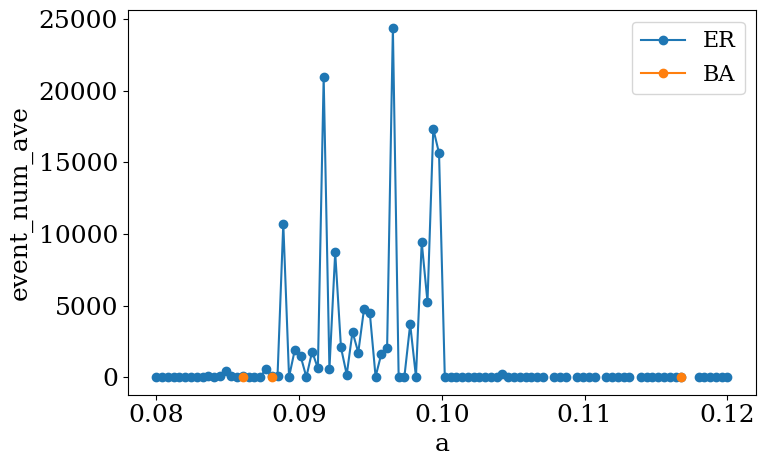

In [34]:
import os
import numpy as np
from multiprocessing import cpu_count
import matplotlib.pyplot as plt

event_num_dict = {}

#---- 設定 ----
data_dir = os.path.join(current_dir, f"data_N={N}")
n_workers = cpu_count()
A = len(a_values)
R = repeats

#---- 1) 各 worker の event_times をキャッシュ ----
worker_data = []
for wid in range(n_workers):
    path = os.path.join(data_dir, f"{wid:02d}_results.npz")
    with np.load(path, allow_pickle=True) as d:
        # d["event_times"] は shape=(A, R) の object 配列
        worker_data.append(d["event_times"])

#---- 2) 合計長さ＆有効サンプル数を a_idx ごとに初期化 ----
total_lengths = np.zeros(A, dtype=float)
valid_counts  = np.zeros(A, dtype=int)

#---- 3) 各 worker のデータから集計 ----
for ev_times in worker_data:
    # 各要素の長さを一括取得 (shape=(A, R))
    lengths = np.vectorize(lambda arr: arr.shape[0])(ev_times)
    # 長さが 100001 でないものだけをカウント対象に
    mask = (lengths != 100001) & (lengths != 1) & (lengths != 2) & (lengths != 3) & (lengths != 4) & (lengths != 5) & (lengths != 6) & (lengths != 7) & (lengths != 8) & (lengths != 9) & (lengths != 10)

    # a_idx ごとに合計長さを足し込み
    total_lengths += (lengths * mask).sum(axis=1)
    # a_idx ごとに有効サンプル数を足し込み
    valid_counts  += mask.sum(axis=1)

#---- 4) 平均を計算 ----
event_num_ave = total_lengths / valid_counts

event_num_dict["ER"] = event_num_ave

#---- 設定 ----
data_dir = os.path.join(current_dir, f"data_BA_N={N}")
n_workers = cpu_count()
A = len(a_values)
R = repeats

#---- 1) 各 worker の event_times をキャッシュ ----
worker_data = []
for wid in range(n_workers):
    path = os.path.join(data_dir, f"{wid:02d}_results.npz")
    with np.load(path, allow_pickle=True) as d:
        # d["event_times"] は shape=(A, R) の object 配列
        worker_data.append(d["event_times"])

#---- 2) 合計長さ＆有効サンプル数を a_idx ごとに初期化 ----
total_lengths = np.zeros(A, dtype=float)
valid_counts  = np.zeros(A, dtype=int)

#---- 3) 各 worker のデータから集計 ----
for ev_times in worker_data:
    # 各要素の長さを一括取得 (shape=(A, R))
    lengths = np.vectorize(lambda arr: arr.shape[0])(ev_times)
    # 長さが 100001 でないものだけをカウント対象に
    mask = (lengths != 100001) & (lengths != 1) & (lengths != 2) & (lengths != 3) & (lengths != 4) & (lengths != 5) & (lengths != 6) & (lengths != 7) & (lengths != 8) & (lengths != 9) & (lengths != 10)

    # a_idx ごとに合計長さを足し込み
    total_lengths += (lengths * mask).sum(axis=1)
    # a_idx ごとに有効サンプル数を足し込み
    valid_counts  += mask.sum(axis=1)

#---- 4) 平均を計算 ----
event_num_ave = total_lengths / valid_counts

event_num_dict["BA"] = event_num_ave



#---- 5) 描画 ----
fig, ax = plt.subplots(figsize=(8, 5))
for key, value in event_num_dict.items():
    ax.plot(a_values, value, marker="o", label=key)
ax.set_xlabel("a")
ax.set_ylabel("event_num_ave")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
import boto3
import os
import sys

current_dir = os.path.dirname(os.path.abspath('.'))
sys.path.append(current_dir)
sys.path.append(os.path.abspath(os.path.join(current_dir, "..")))

from s3.s3_io import download_from_s3

download_from_s3("hawkes_N=100_z=10/a_values.npy", "a_values.npy")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from tqdm import tqdm
from scipy import integrate
from typing import Callable, List
from dataclasses import dataclass

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

# ── 1. パラメータクラスを拡張 ────────────────────────────────────

class HawkesParams:
    def __init__(self, kernel: Callable[[float], float], dim: int, a: float, b: float, K: float, c: float, theta: float, a_ij: float = 1, rho: np.ndarray = None):
        self.kernel = kernel
        self.dim = dim
        self.a = a
        self.b = b
        self.K = K
        self.c = c
        self.theta = theta
        self.a_ij = a_ij
        self.rho = np.zeros(dim) if rho is None else rho

# ── 2. ネットワーク生成はそのまま ─────────────────────────────────

class Network():
    def __init__(self, N: int, k_ave: float, edge_list: np.ndarray[int], address_list: np.ndarray[int], cursor_list: np.ndarray[int]):
        self.N = N
        self.k_ave = k_ave
        self.edge_list = edge_list
        self.address_list = address_list
        self.cursor_list = cursor_list

# ── 3. カーネル関数の定義 ────────────────────────────────────────────

def kernel_exp(tau: np.ndarray, p: HawkesParams) -> np.ndarray:
    """指数関数カーネル:  g(t)=a·b·exp(-b·t)·1_{t>=0}"""
    a = p.a
    b = p.b
    return a * b * np.exp(-b * tau) * (tau >= 0)

def kernel_pow(tau: np.ndarray, p: HawkesParams) -> np.ndarray:
    """冪函数カーネル:  g(t)=K/(t+c)^{1+θ}·1_{t>=0}"""
    K = p.K
    c = p.c
    theta = p.theta
    return K * (tau + c)**(-(1 + theta)) * (tau >= 0)

def create_er_network(N: int, p: float) -> Network:
    # …（省略、元コードと同じ）…
    g = nx.erdos_renyi_graph(N, p)
    k_ave = np.mean([len(list(g.neighbors(n))) for n in g.nodes])
    edge_list = np.zeros(2*g.number_of_edges(), dtype=int)
    address_list = np.zeros(N, dtype=int)
    cursor_list = np.zeros(N, dtype=int)
    for i, node in enumerate(g.nodes):
        if i>0:
            address_list[node] = address_list[prev] + len(list(g.neighbors(prev)))
        cursor_list[node] = address_list[node]
        prev = node
    for u, v in g.edges:
        edge_list[cursor_list[u]] = v
        edge_list[cursor_list[v]] = u
        cursor_list[u] += 1
        cursor_list[v] += 1
    return Network(g.number_of_nodes(), k_ave, edge_list, address_list, cursor_list)

# ── 4. 強度計算関数 ────────────────────────────────────────
def thinning_rate(lamb_star: np.ndarray, elapsed: float, p: HawkesParams, g: Network) -> np.ndarray:
    """Conditional intensity function."""
    if p.kernel is kernel_exp:
        return p.rho + (lamb_star - p.rho) * np.exp(-p.b * elapsed)
    elif p.kernel is kernel_pow:
        return p.rho + (lamb_star - p.rho) * (elapsed + p.c)**(-(1 + p.theta))
    else:
        raise ValueError("Invalid kernel")

def lamb_i(i: int,
           t: np.ndarray,
           event_times: List[float],
           event_nodes: List[int],
           p: HawkesParams,
           g: Network) -> np.ndarray:
    """
    時刻 t におけるノード i の強度 λ_i(t)
    全履歴上の kernel を総和して計算。
    """
    dim_i = g.cursor_list[i] - g.address_list[i]
    dt = np.zeros((dim_i, len(event_times)))

    sigma_j = np.zeros((dim_i, len(t)))

    for jidx in range(dim_i):
        j = g.edge_list[g.address_list[i] + jidx]
        history = []
        for eidx, et in enumerate(event_times):
            if event_nodes[eidx] == j:
                history.append(et)
        dt = t[:, None] - np.array(history)[None, :]
        sigma_j[jidx, :] = p.kernel(dt, p).sum(axis=1)

    return p.rho[i] + sigma_j.sum(axis=0) * p.a_ij

# ── 5. シミュレーション関数（汎用版）────────────────────────────

def simulate_hawkes_generic(t_max: float,
                            initial_infected_num: int,
                            p: HawkesParams,
                            g: Network,
                            max_events: int = 100000) -> np.ndarray:
    
    t_star = 0.0
    event_times: List[float] = []
    event_nodes: List[int] = []

    # 初期上限レートは全基底強度の和
    initial_infected = np.random.choice(g.N, initial_infected_num, replace=False)
    lamb_star = np.zeros(g.N)
    for node in initial_infected:
        lamb_star[node] = p.kernel(0, p)
    event_times: List[float] = [0]
    event_nodes: List[int] = initial_infected.tolist()


    while t_star < t_max and len(event_times) < max_events:
        # 1) 次の候補時刻をサンプリング
        wait = np.random.exponential(1.0 / lamb_star.sum())
        t_star += wait
        if t_star > t_max:
            break

        # サンプリングした時間にイベントが起きたとするかどうか判定
        current_intensity = thinning_rate(lamb_star, wait, p, g)
        accept_prob =  current_intensity.sum() / lamb_star.sum()
        if accept_prob >= np.random.rand():
            event_times.append(t_star)

            probs = current_intensity.copy()
            probs = np.clip(probs, 0, None)
            total = probs.sum()
            if total <= 0:
                break
            probs = probs / total
            # 最も大きい要素に「1 - sum(probs)」を足して、
            # 合計を厳密に 1 にする
            imax = np.argmax(probs)
            probs[imax] += 1.0 - probs.sum()

            # ここで絶対に sum(probs)==1 かつ probs>=0 になる
            node = np.random.choice(p.dim, p=probs)
            event_nodes.append(int(node))
            
            lamb_star = current_intensity
            for neighbor in g.edge_list[g.address_list[node]:g.cursor_list[node]]:
                lamb_star[neighbor] += p.kernel(0, p) * p.a_ij # カーネル関数は全ての次元で同じとしている。
            if len(event_times) > max_events:
                break
        else:
            lamb_star = current_intensity

    return np.array(event_times), np.array(event_nodes)




K=0.05
K=4


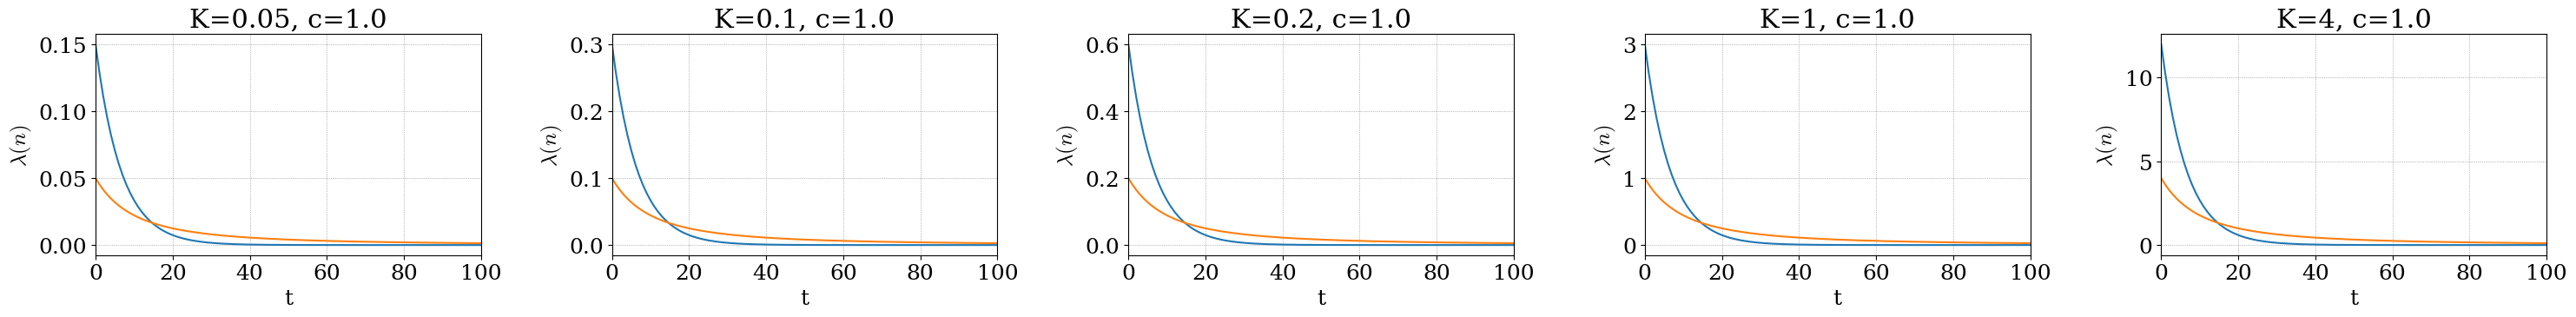

In [11]:
b = 3
K_values = [0.05, 0.1, 0.2, 1, 4]
theta = 1.0
c = 1.0
N = 1000
t = np.linspace(0, 50, 1000)

fig, axes = plt.subplots(nrows=1, ncols=len(K_values), figsize=(6 * len(K_values), 4))

for kidx, K in enumerate(K_values):
    is_print = kidx%10==0 or kidx==len(K_values)-1
    if is_print:
        print(f"K={K}")

    params = HawkesParams(dim=N, a=K, b=b, K=K, c=c, theta=theta, a_ij=1, kernel=kernel_pow)
    exp = kernel_exp(t, params)
    pow = kernel_pow(t, params)
    axes[kidx].plot(exp, label="exp")
    axes[kidx].plot(pow, label="pow")
    axes[kidx].set_xlabel("t")
    axes[kidx].set_ylabel(rf"$\lambda(n)$")
    axes[kidx].set_title(rf"K={K}, c={c}")
    axes[kidx].grid(linestyle=":")
    axes[kidx].set_xlim(0, 100)
fig.tight_layout()
plt.show()